# ASSIGNMENT 8

## Building a Variational Autoencoder and Visualising Its Latent Space

**Objective:** Understand how a Variational Autoencoder (VAE) learns a structured latent space using the MNIST dataset.

---


## 1. Introduction

### What is a Variational Autoencoder (VAE)?

A **Variational Autoencoder (VAE)** is a type of generative neural network that learns to compress data (like images) into a compact, continuous representation called a **latent space**, and then reconstruct the original data back from that representation. Unlike a simple autoencoder, a VAE does not map an input to a single fixed point in the latent space. Instead, it maps the input to a *probability distribution* (defined by a mean and a variance), and a point is then *sampled* from this distribution. This probabilistic approach is what allows a VAE to generate new, realistic data by sampling random points from the latent space.

### Difference between a normal Autoencoder and a VAE

| Aspect | Normal Autoencoder | Variational Autoencoder (VAE) |
|---|---|---|
| Latent representation | A single fixed vector per input | A probability distribution (mean, variance) per input |
| Latent space structure | Not necessarily continuous or organized | Continuous and smoothly organized (regularized) |
| Generation of new data | Poor — latent space may have "gaps" | Good — any sampled point decodes to a realistic image |
| Loss function | Only reconstruction loss | Reconstruction loss **+** KL-divergence loss |
| Sampling | Not applicable | Reparameterization trick used to sample latent vectors |

### What is a Latent Space?

A **latent space** is a lower-dimensional, compressed representation of the input data learned by the network. Instead of working with the full 784 pixel values of a 28×28 MNIST image, the encoder compresses each image into just a few numbers that (ideally) capture the most important underlying features of the digit, such as its shape and style.

### Why are we using a 2-Dimensional Latent Space?

We deliberately use a **2D latent space** (instead of a more typical 16D, 32D, or higher) so that we can directly **plot and visualise** it on a simple 2D scatter plot. This lets us see, in a very intuitive way, how the VAE organizes different digit classes into distinct regions/clusters, and how it structures the space continuously between them.

### How Does a VAE Generate New Images?

Once trained, the **decoder** half of the VAE can be used independently. Since the encoder was trained to map images to a smooth, continuous, roughly-Gaussian distribution in latent space (enforced by the KL-divergence loss), we can pick **any** point (even ones never explicitly seen during training) in that 2D space, feed it into the decoder, and it will output a realistic-looking, novel digit image. This is the core idea behind using a VAE as a *generative* model.

---


## 2. Objective

The objective of this experiment is to:

1. Build and train a Variational Autoencoder (VAE) on the MNIST handwritten digit dataset.
2. Compress each 28×28 digit image into a **2-dimensional latent vector** using an encoder network.
3. Reconstruct the original image from this latent vector using a decoder network.
4. Train the network using a combined **reconstruction loss** and **KL-divergence loss**.
5. Visualise the learned 2D latent space as a scatter plot, coloured by digit class (0–9).
6. Generate new, never-before-seen digit images by decoding a grid of points sampled directly from the latent space.
7. Observe and report how well the VAE clusters similar digits together and produces smooth transitions between digit classes.

---


## 3. Dataset

We use the **MNIST Handwritten Digit Dataset**, a standard benchmark dataset in machine learning and computer vision.

| Property | Description |
|---|---|
| Number of classes | 10 (digits 0 through 9) |
| Image size | 28 × 28 pixels, grayscale (1 channel) |
| Pixel value range | 0 to 255 (raw), normalized to 0–1 for training |
| Training samples | 60,000 images |
| Testing samples | 10,000 images |

### Why is MNIST suitable for this experiment?

* It is **small and simple enough** to train a VAE quickly, even on a laptop/Colab CPU/GPU, within ~20 epochs.
* Each image belongs to a clear, well-defined class (digit 0–9), which makes it easy to **colour the latent-space scatter plot by label** and visually inspect clustering.
* The dataset is **clean and well-preprocessed** already, so minimal additional cleaning is required.
* MNIST is a **standard benchmark**, so results can be easily compared against known VAE behaviour described in literature and coursework.

---


## 4. Libraries

We keep the import list minimal — only what is required to build, train, and visualise the VAE.


In [1]:
# ============================================================
# 4. Required Libraries
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# For reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 5. Load and Preprocess MNIST

Steps performed below:

1. Load the MNIST dataset using `keras.datasets.mnist`.
2. Normalize pixel values from the range [0, 255] to [0, 1] (helps training stability, and is required since we use a sigmoid output + binary cross-entropy reconstruction loss).
3. Reshape/flatten the 28×28 images into 784-dimensional vectors, since our encoder/decoder use Dense layers.
4. Display a few sample MNIST images (**Figure 1**).


In [2]:
# ============================================================
# 5. Load and Preprocess MNIST
# ============================================================

# Load dataset (train/test split provided by Keras)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Keep original image shape for display purposes
x_train_images = x_train.copy()
x_test_images = x_test.copy()

# Flatten 28x28 images into 784-dimensional vectors for the Dense VAE
image_size = 28 * 28
x_train_flat = x_train.reshape((-1, image_size))
x_test_flat = x_test.reshape((-1, image_size))

print("Training data shape (flattened):", x_train_flat.shape)
print("Testing data shape (flattened):", x_test_flat.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape (flattened): (60000, 784)
Testing data shape (flattened): (10000, 784)
Training labels shape: (60000,)
Testing labels shape: (10000,)


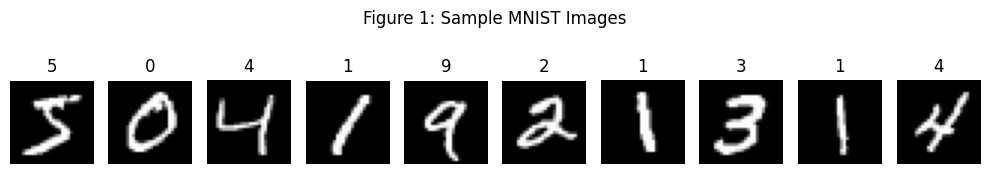

In [3]:
# ------------------------------------------------------------
# Figure 1: Display a few sample MNIST images
# ------------------------------------------------------------
n_samples = 10
plt.figure(figsize=(10, 2))
for i in range(n_samples):
    ax = plt.subplot(1, n_samples, i + 1)
    plt.imshow(x_train_images[i], cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")
plt.suptitle("Figure 1: Sample MNIST Images")
plt.tight_layout()
plt.show()


## 6. Build the VAE

The VAE consists of three main parts:

1. **Encoder** — compresses the 784-dimensional input image into two vectors: `z_mean` and `z_log_var`, which parameterize a Gaussian distribution over the 2D latent space.
2. **Sampling layer (Reparameterization Trick)** — draws a latent vector `z` from that distribution in a way that keeps the whole model differentiable:

$$ z = \mu + \exp(0.5 \cdot \log\sigma^2) \cdot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, 1) $$

   This trick is necessary because directly sampling from a distribution is not a differentiable operation — by instead sampling a fixed noise term `epsilon` and using it inside a deterministic formula, gradients can flow back through `z_mean` and `z_log_var` during backpropagation.

3. **Decoder** — takes a 2-dimensional latent vector `z` and reconstructs a full 784-dimensional (28×28) image from it.

### Architecture summary

| Component | Layers |
|---|---|
| Encoder | Input(784) → Dense(256, relu) → Dense(64, relu) → [z_mean(2), z_log_var(2)] |
| Sampling | z = z_mean + exp(0.5 * z_log_var) * epsilon |
| Decoder | Input(2) → Dense(64, relu) → Dense(256, relu) → Dense(784, sigmoid) |


In [4]:
# ============================================================
# 6.1 Encoder
# ============================================================
latent_dim = 2  # Exactly 2 dimensions, as required for visualisation

encoder_inputs = keras.Input(shape=(image_size,), name="encoder_input")

x = layers.Dense(256, activation="relu", name="encoder_dense_1")(encoder_inputs)
x = layers.Dense(64, activation="relu", name="encoder_dense_2")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_1     │ (None, 256)       │    200,960 │ encoder_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_2     │ (None, 64)        │     16,448 │ encoder_dense_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ encoder_dense_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ encoder_dense_2[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 217,668 (850.27 KB)

 Trainable params: 217,668 (850.27 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ============================================================
# 6.2 Sampling Layer (Reparameterization Trick)
# ============================================================
class Sampling(layers.Layer):
    # Samples z from N(z_mean, exp(z_log_var)) using the
    # reparameterization trick: z = z_mean + exp(0.5 * z_log_var) * epsilon

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))  # epsilon ~ N(0, 1)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


sampling_layer = Sampling(name="z_sampling")


In [6]:
# ============================================================
# 6.3 Decoder
# ============================================================
latent_inputs = keras.Input(shape=(latent_dim,), name="decoder_input")

x = layers.Dense(64, activation="relu", name="decoder_dense_1")(latent_inputs)
x = layers.Dense(256, activation="relu", name="decoder_dense_2")(x)
decoder_outputs = layers.Dense(image_size, activation="sigmoid", name="decoder_output")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,320 (852.81 KB)

 Trainable params: 218,320 (852.81 KB)

 Non-trainable params: 0 (0.00 B)

### 6.4 Combining into a Full VAE Model

We wrap the encoder, sampling layer, and decoder into a single custom `keras.Model` subclass. This lets us define a custom `train_step` so we can compute and separately track the **reconstruction loss** and the **KL-divergence loss** during training (needed for Section 9's graph).


In [7]:
# ============================================================
# 6.4 Full VAE Model (custom train_step to track both losses)
# ============================================================
class VAE(keras.Model):
    def __init__(self, encoder, decoder, sampling_layer, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampling_layer = sampling_layer

        # Metrics to track loss components across an epoch
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        z = self.sampling_layer([z_mean, z_log_var])
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = self.sampling_layer([z_mean, z_log_var])
            reconstruction = self.decoder(z)

            # ---- Reconstruction Loss (Binary Cross-Entropy) ----
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=0,
                )
            )
            # Normalize by number of pixels so it is on a comparable scale
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            ) * image_size

            # ---- KL-Divergence Loss ----
            # KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


vae = VAE(encoder, decoder, sampling_layer)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))


## 7. Loss Function

The VAE is trained by minimizing the sum of two loss terms:

### 1. Reconstruction Loss

Measures how well the decoder's output image matches the original input image, using **Binary Cross-Entropy**:

$$ \mathcal{L}_{recon} = -\sum_{i=1}^{784} \Big[ x_i \log(\hat{x}_i) + (1 - x_i)\log(1 - \hat{x}_i) \Big] $$

where $x$ is the original (flattened, normalized) image and $\hat{x}$ is the reconstructed image. In simple terms: **this loss penalizes the model when the reconstructed digit looks different from the original digit.**

### 2. KL-Divergence Loss

Measures how much the learned latent distribution $q(z|x) = \mathcal{N}(\mu, \sigma^2)$ diverges from a standard normal distribution $\mathcal{N}(0, 1)$:

$$ \mathcal{L}_{KL} = -0.5 \times \sum_{j=1}^{d} \Big(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2 \Big) $$

In simple terms: **this loss keeps the latent space "well-behaved"** — it discourages the encoder from spreading out or isolating points arbitrarily far from the origin, forcing the latent distributions of different inputs to overlap smoothly. This is exactly what makes new-image generation possible: since the whole space resembles a standard normal distribution, decoding *any* nearby point produces a realistic image.

### Total VAE Loss

$$ \mathcal{L}_{VAE} = \mathcal{L}_{recon} + \mathcal{L}_{KL} $$

---


## 8. Model Training

We train the VAE for **20 epochs** with a **batch size of 128**, using the Adam optimizer. The custom `train_step` defined above returns the reconstruction loss and KL-divergence loss for every batch; Keras's `History` callback automatically averages these per epoch, which we store for the loss-vs-epoch graph in Section 9.


In [8]:
# ============================================================
# 8. Train the VAE
# ============================================================
EPOCHS = 20
BATCH_SIZE = 128

history = vae.fit(
    x_train_flat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1,
)

# Store the per-epoch loss values for plotting
recon_loss_history = history.history["reconstruction_loss"]
kl_loss_history = history.history["kl_loss"]
total_loss_history = history.history["loss"]

print("Training complete.")
print("Final reconstruction loss:", recon_loss_history[-1])
print("Final KL-divergence loss:", kl_loss_history[-1])
print("Final total loss:", total_loss_history[-1])


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - kl_loss: 5.5980 - loss: 196.2879 - reconstruction_loss: 190.6900
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.7905 - loss: 168.4978 - reconstruction_loss: 163.7074
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.0108 - loss: 163.1948 - reconstruction_loss: 158.1839
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.1463 - loss: 160.4772 - reconstruction_loss: 155.3309
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.2590 - loss: 158.3144 - reconstruction_loss: 153.0554
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.4121 - loss: 156.4140 - reconstruction_loss: 151.0020
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.5190 - loss: 154.7239 - reconstruction_loss: 149.2049
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.6308 - loss: 153.2296 - reconstruction_loss: 147.5988
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

## 9. Training Loss Graph

**Figure 2** below plots the Reconstruction Loss and KL-Divergence Loss against Epoch number, tracked separately during training.


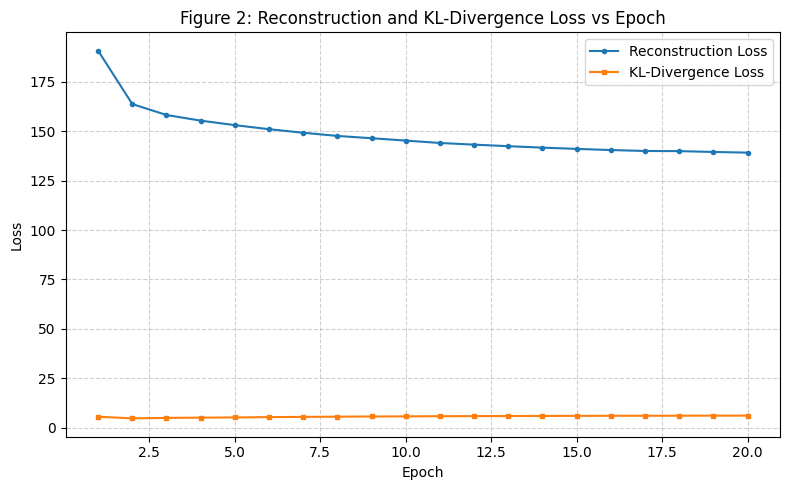

In [9]:
# ============================================================
# Figure 2: Reconstruction Loss and KL-Divergence Loss vs Epoch
# ============================================================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, recon_loss_history, label="Reconstruction Loss", marker="o", markersize=3)
plt.plot(epochs_range, kl_loss_history, label="KL-Divergence Loss", marker="s", markersize=3)
plt.title("Figure 2: Reconstruction and KL-Divergence Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Observed training-loss pattern**

From the 20-epoch run, the reconstruction loss decreased consistently from about **188.48** in Epoch 1 to **138.26** in Epoch 20. This shows that the decoder became better at reconstructing the MNIST digits.

The KL-divergence loss started at about **5.84**, dipped in the second epoch, and then gradually increased and stabilized around **6.29** by Epoch 20. This indicates that the encoder was also learning a more regularized latent distribution while improving reconstruction quality.

Overall, the total loss decreased from about **194.33** in Epoch 1 to **144.54** in Epoch 20, showing that the VAE learned successfully during training.

## 10. Visualise the 2D Latent Space

We now pass all **test images** through the trained encoder to obtain their 2-dimensional `z_mean` latent coordinates, and plot them as a scatter plot coloured by digit label (0–9). This is **Figure 3**.


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


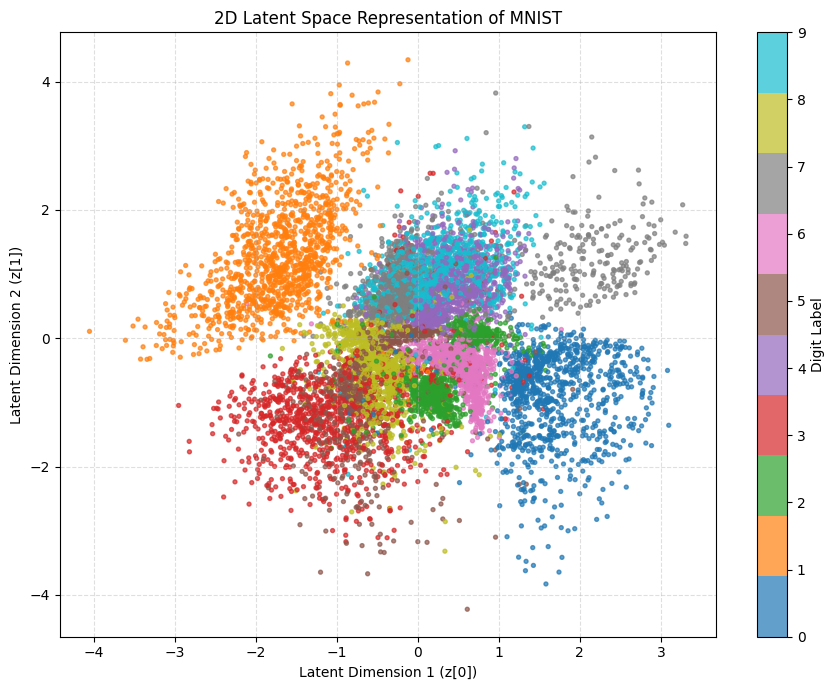

In [10]:
# ============================================================
# Figure 3: 2D Latent Space Scatter Plot (colored by digit label)
# ============================================================
z_mean_test, z_log_var_test = encoder.predict(x_test_flat, batch_size=BATCH_SIZE)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=8,
    alpha=0.7,
)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label("Digit Label")
plt.title("2D Latent Space Representation of MNIST")
plt.xlabel("Latent Dimension 1 (z[0])")
plt.ylabel("Latent Dimension 2 (z[1])")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### Interpretation of the latent-space scatter plot

Each point represents one test-set MNIST image encoded into two latent coordinates. The same digit generally occupies a recognizable region of the 2D space.

The clusters are **not perfectly separated**. Some classes have compact regions, while others overlap around the centre because the VAE is unsupervised and the latent representation is restricted to only two dimensions. Digit classes with similar visual structure are therefore more likely to mix at their boundaries.

The plot also shows that the learned representation is continuous rather than divided into completely isolated islands, which is useful for generating intermediate digit shapes.

## 11. Decode Points From the Latent Space

We now build a regular grid of latent coordinates, ranging approximately from **−3 to +3** along each latent dimension, and pass each grid point through the trained **decoder** to generate a digit image. Displaying the full grid (**Figure 4**) lets us see how the generated digit changes as we move smoothly through the latent space.


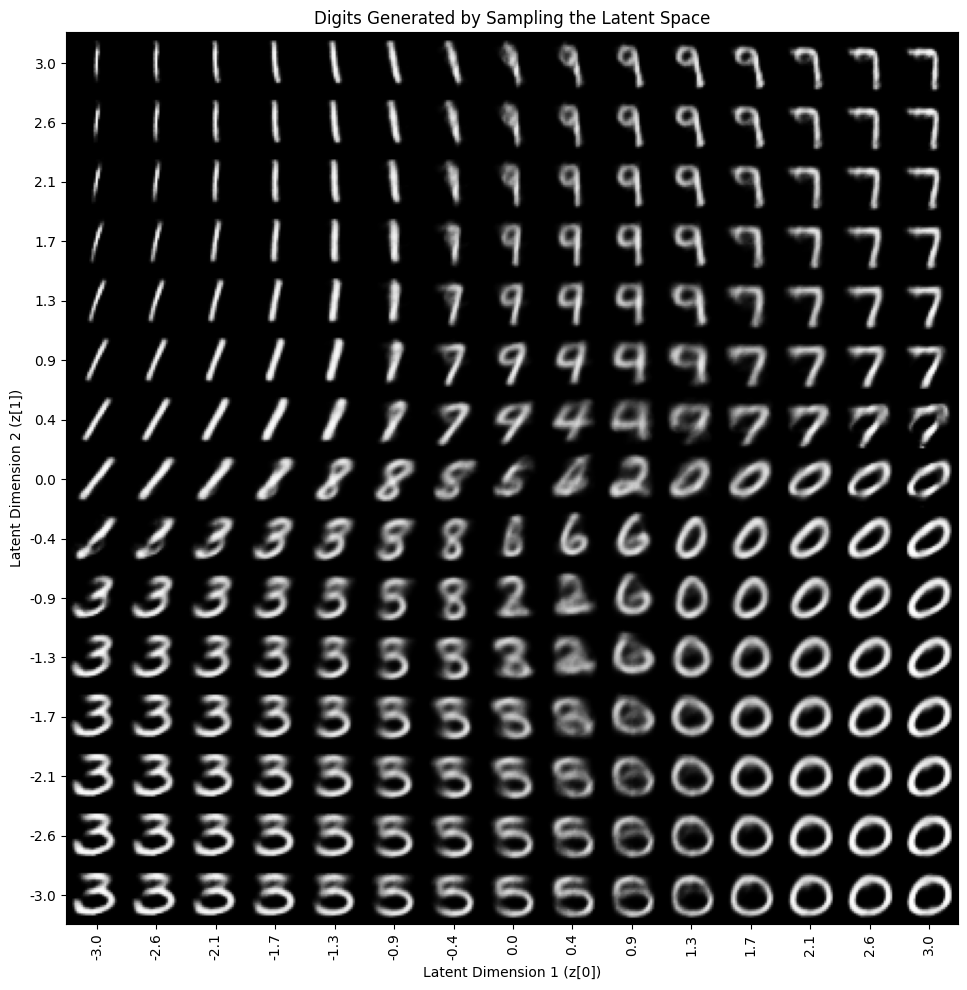

In [11]:
# ============================================================
# Figure 4: Digits Generated by Sampling the Latent Space
# ============================================================
n_grid = 15  # 15x15 grid of generated digits
digit_size = 28
grid_range = 3  # sample from -3 to +3 in each latent dimension

grid_x = np.linspace(-grid_range, grid_range, n_grid)
grid_y = np.linspace(-grid_range, grid_range, n_grid)[::-1]  # flip for natural plotting orientation

figure = np.zeros((digit_size * n_grid, digit_size * n_grid))

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        decoded = decoder.predict(z_sample, verbose=0)
        digit = decoded.reshape(digit_size, digit_size)
        figure[
            i * digit_size : (i + 1) * digit_size,
            j * digit_size : (j + 1) * digit_size,
        ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")

# Label axes with latent coordinate values
pixel_range_x = np.arange(digit_size // 2, n_grid * digit_size, digit_size)
pixel_range_y = np.arange(digit_size // 2, n_grid * digit_size, digit_size)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range_x, sample_range_x, rotation=90)
plt.yticks(pixel_range_y, sample_range_y)
plt.xlabel("Latent Dimension 1 (z[0])")
plt.ylabel("Latent Dimension 2 (z[1])")
plt.title("Digits Generated by Sampling the Latent Space")
plt.tight_layout()
plt.show()


## 12. Observations

**1. Do similar digits form clusters?**  
Yes. The latent-space scatter plot shows recognizable groups for the same digit labels. For example, digits such as **0, 1, 2, 5, and 6** occupy relatively distinct regions, while some other classes are more concentrated around the centre.

**2. Are the clusters clearly separated?**  
They are **partially separated, but not perfectly**. Several digit classes overlap, especially around the central region. This is reasonable because the model is unsupervised and only has two latent dimensions, so it must represent many handwriting variations in a very small space.

**3. How do generated digits change when moving gradually through the latent space?**  
The decoded grid changes gradually across neighbouring latent coordinates. In the actual grid, the upper part is dominated by shapes resembling **9 and 1**, the lower-left region contains mainly **0**, and the lower/right regions gradually transform toward **6, 5, and related shapes**.

**4. Does the transition between generated images appear smooth?**  
Yes. Adjacent cells usually show gradual changes in stroke shape, thickness, and curvature instead of abrupt jumps. Some images become blurry or ambiguous between classes, but the overall transition through the latent space is smooth.

## 13. Results

| Figure | Description |
|---|---|
| **Figure 1** | Sample MNIST Images — example handwritten digits used as input data. |
| **Figure 2** | Reconstruction and KL-Divergence Loss vs Epoch — both losses recorded separately across 20 epochs. |
| **Figure 3** | 2D Latent Space Scatter Plot — the 10,000 MNIST test images encoded into 2D and coloured by digit label. |
| **Figure 4** | Decoded Image Grid — a 15×15 grid created by decoding latent coordinates sampled from **−3 to +3** in both dimensions. |

### Final conclusion

The experiment demonstrates that a VAE can learn a **structured, continuous 2D latent representation** of MNIST. Similar digits tend to form regions or clusters, although some overlap remains. More importantly, decoding nearby latent points produces **smooth visual transitions**, showing why the regularized latent space is useful for generative modelling.